In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data

#df = pd.read_csv('fromCale/daily_data_pl.csv')
df = pd.read_csv('fromCale/daily_data_nl.csv')
df

,utc_timestamp,NL_load_actual_entsoe_transparency
0,2015-01-01 00:00:00+00:00,10283.833333
1,2015-01-02 00:00:00+00:00,11931.250000
2,2015-01-03 00:00:00+00:00,12920.250000
3,2015-01-04 00:00:00+00:00,12529.250000
4,2015-01-05 00:00:00+00:00,15715.708333
...,...,...
1821,2019-12-27 00:00:00+00:00,13221.916667
1822,2019-12-28 00:00:00+00:00,12964.208333
1823,2019-12-29 00:00:00+00:00,12607.125000
1824,2019-12-30 00:00:00+00:00,13258.166667


In [2]:
# Select data for training # 
fra = '2018-01-01'
til = '2018-12-31'
# Using between method (inclusive of both endpoints)
#data_2018 = df.loc[df['utc_timestamp'].between('2015-01-01', '2015-03-01')]
df = df.loc[(df['utc_timestamp'] >= fra) & (df['utc_timestamp'] <= til)]
df = df.rename(columns={'utc_timestamp': 'ds', 'NL_load_actual_entsoe_transparency': 'consumption'})

df

,ds,consumption
1096,2018-01-01 00:00:00+00:00,11692.250000
1097,2018-01-02 00:00:00+00:00,14106.333333
1098,2018-01-03 00:00:00+00:00,14755.000000
1099,2018-01-04 00:00:00+00:00,14686.291667
1100,2018-01-05 00:00:00+00:00,14471.375000
...,...,...
1455,2018-12-26 00:00:00+00:00,12443.250000
1456,2018-12-27 00:00:00+00:00,13891.916667
1457,2018-12-28 00:00:00+00:00,14056.375000
1458,2018-12-29 00:00:00+00:00,13064.666667


In [3]:
# Convert the time column to datetime and set as index
# Replace 'timestamp_column' with the actual name in your CSV
df['timestamp'] = pd.to_datetime(df['ds'])
df = df.set_index('timestamp').sort_index()

# Quick check for missing hours
print(f"Dataset range: {df.index.min()} to {df.index.max()}")
df.head()

Dataset range: 2018-01-01 00:00:00+00:00 to 2018-12-30 00:00:00+00:00


,ds,consumption
timestamp,,
2018-01-01 00:00:00+00:00,2018-01-01 00:00:00+00:00,11692.250000
2018-01-02 00:00:00+00:00,2018-01-02 00:00:00+00:00,14106.333333
2018-01-03 00:00:00+00:00,2018-01-03 00:00:00+00:00,14755.000000
2018-01-04 00:00:00+00:00,2018-01-04 00:00:00+00:00,14686.291667
2018-01-05 00:00:00+00:00,2018-01-05 00:00:00+00:00,14471.375000



# Engineering features

In [4]:

df['date'] = pd.to_datetime(df['ds'])
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
df['day_of_year'] = df['date'].dt.dayofyear
df['is_month_start'] = df['date'].dt.is_month_start.astype(int)

#Lag Features: Value from 1 day ago and 7 days ago
df['lag_1'] = df['consumption'].shift(1)
df['lag_7'] = df['consumption'].shift(7)

# Rolling Mean: Average of the last 7 days (captures the recent trend)
df['rolling_mean_7'] = df['consumption'].shift(1).rolling(window=7).mean()

In [5]:
# Define features and target
features = ['day_of_week', 'month', 'week_of_year', 'lag_1', 'lag_7', 'rolling_mean_7']
target = 'consumption'

# Split
train_df = df[df['date'] < '2018-11-01']
test_df = df[df['date'] >= '2018-11-01']


X_train, y_train = train_df[features], train_df[target]
X_test, y_test = test_df[features], test_df[target]


In [6]:
import lightgbm as lgb

model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01, # Slow and steady
    num_leaves=31,
    importance_type='gain', 
    #max_depth=6,
    #random_state=42
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000140 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 368
[LightGBM] [Info] Number of data points in the train set: 304, number of used features: 6
[LightGBM] [Info] Start training from score 12916.069371
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 50 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -i

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.01
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [7]:
y_pred= model.predict(X_test)


# Option 2

import lightgbm as lgb

# LightGBM Dataset parameters
params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.03, # Lower learning rate for small datasets
    'num_leaves': 20,      # Keep this small to prevent overfitting 365 rows
    'feature_fraction': 0.8
}

train_data = lgb.Dataset(train_df[features], label=train_df['consumption'])
test_data = lgb.Dataset(test_df[features], label=test_df['consumption'], reference=train_data)

model = lgb.train(params, train_data, valid_sets=[test_data], num_boost_round=500)

In [8]:
import pandas as pd

# 1. Ubah y_pred (array) menjadi DataFrame
# Pastikan index-nya sama dengan y_test agar kolom 'ds' sinkron
df_pred = pd.DataFrame({'lgbm': y_pred}, index=y_test.index)

# 2. Jika 'ds' adalah index di y_test, gunakan ini:
result = pd.merge(y_test, df_pred, left_index=True, right_index=True)

# ATAU jika 'ds' adalah kolom biasa di y_test:
#df_pred['ds'] = y_test['ds'].values
#result = pd.merge(y_test, df_pred, on='ds', how='inner')


In [9]:
print(result.columns)

Index(['consumption', 'lgbm'], dtype='object')



# metrics rRMSE and rMAE

In [10]:
import numpy as np
# 1. Calculate the Mean of Actual Values (Denominator)
y_mean = np.mean(result['consumption'])

# 2. Calculate rMAE (Relative Mean Absolute Error)
mae = np.mean(np.abs(result['consumption'] - result['lgbm']))
rmae = mae / y_mean

# 3. Calculate rRMSE (Relative Root Mean Square Error)
rmse = np.sqrt(np.mean((result['consumption'] - result['lgbm'])**2))
rrmse = rmse / y_mean

metricResult = f'rRMSE: {rrmse:.4f} rMAE: {rmae:.4f} '
print(metricResult)


rRMSE: 0.0504 rMAE: 0.0412 


In [12]:
city = 'Daily Netherland lgbm'

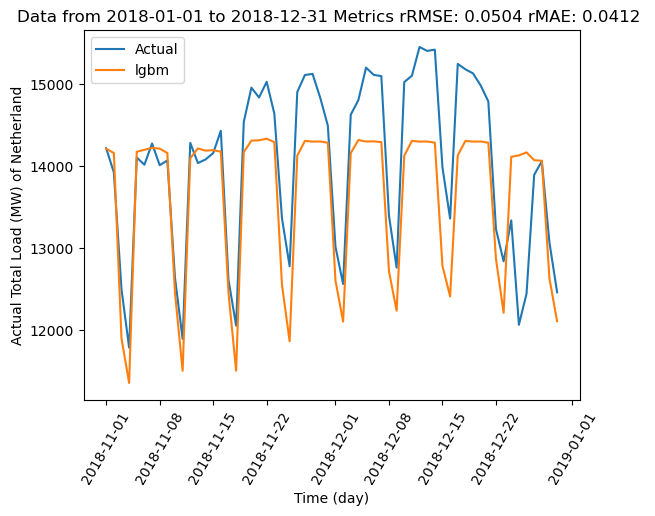

In [13]:
# plot Result dan save

plt.plot(result.index, result['consumption'], label='Actual')
plt.plot(result.index, result['lgbm'],label='lgbm')
#plt.plot(fcst_df['ds'], fcst_df['TimeGPT-hi-80'])

# Menambahkan label sumbu dan judul plot
plt.xlabel('Time (day)')
plt.xticks(rotation=60)  # Rotate labels by 45 degrees
plt.ylabel('Actual Total Load (MW) of Netherland')
#plt.title('Plot of Combined Value over Date')
plt.title(f'Data from {fra} to {til} Metrics {metricResult}')


# Menambahkan legenda
plt.legend()

# Mengganti spasi dan karakter khusus dengan garis bawah
#result_cleaned = result.replace(' ', '_').replace(':', '_')

# Menyimpan plot ke file gambar dengan judul yang diperbarui
#plt.savefig(f'./time_gpt/result_pure_time_gpt_{result_cleaned}.png')
plt.savefig(f'Plot {city} from {fra} to {til} metric {metricResult}.png', dpi=300, bbox_inches='tight')

# Menampilkan plot
plt.show()
